# IMDb Spoiler Detection Using NLP

This notebook follows a report-style layout inspired by the reference sentiment-analysis project.
It starts with data loading and inspection, then moves through preprocessing, TF-IDF feature extraction, Logistic Regression training, evaluation, error analysis, and interpretation of the most important cues.


## 1. Introduction

**Objective:**

This project aims to detect spoiler comments in IMDb reviews using a transparent text classification pipeline.
The final workflow uses stemming for preprocessing, word TF-IDF for feature extraction, and Logistic Regression for classification.

**Why this task matters:**

- Spoiler detection is a practical text classification problem with noisy user-generated text.
- The task needs both predictive performance and interpretability.
- A linear model makes it easier to inspect which words are associated with spoiler and non-spoiler comments.


## 2. Data Description

**Dataset source:**

- IMDb review and movie metadata files provided in the coursework workspace.

**Data overview:**

- Review file: `IMDB_reviews.json`
- Movie detail file: `IMDB_movie_details.json`
- Main review fields used in this notebook:
  - `review_text`
  - `is_spoiler`
  - `movie_id`
  - `review_summary`
  - `rating`

**Working strategy:**

The raw review file is very large, so the notebook uses reservoir sampling to create a manageable analysis sample for live demonstration.


In [11]:
from pathlib import Path
import json
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from scipy.sparse import vstack
from sklearn.model_selection import GroupShuffleSplit

# pd.set_option('display.max_colwidth', None)
sns.set_style('whitegrid')

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
REVIEW_PATH = DATA_DIR / 'IMDB_reviews.json'
MOVIE_PATH = DATA_DIR / 'IMDB_movie_details.json'

RANDOM_SEED = 42
SAMPLE_SIZE = 30000
stemmer = PorterStemmer()


In [12]:
def read_jsonl(path):
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            yield json.loads(line)


def reservoir_sample_jsonl(path, sample_size=SAMPLE_SIZE, seed=RANDOM_SEED):
    rng = random.Random(seed)
    sample = []
    seen = 0
    for record in read_jsonl(path):
        seen += 1
        if len(sample) < sample_size:
            sample.append(record)
        else:
            j = rng.randint(0, seen - 1)
            if j < sample_size:
                sample[j] = record
    return pd.DataFrame.from_records(sample)


def load_movie_details_df(path):
    return pd.DataFrame.from_records(read_jsonl(path))


def merge_review_movie_data(reviews, movies):
    return reviews.merge(movies, on='movie_id', how='left', suffixes=('', '_movie'))


def group_movie_split(frame, test_size=0.15, random_state=RANDOM_SEED):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(frame, frame['is_spoiler'], groups=frame['movie_id']))
    return frame.iloc[train_idx].reset_index(drop=True), frame.iloc[test_idx].reset_index(drop=True)


def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def stemming_clean(text):
    cleaned = basic_clean(text)
    return ' '.join(stemmer.stem(token) for token in cleaned.split())


def summarize_predictions(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='binary',
        zero_division=0,
    )
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'classification_report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
        'binary_scores': {
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1),
            'support': int(np.sum(np.asarray(y_true).astype(int))),
        },
    }


def top_nonzero_features(vectorizer, sparse_row, top_n=15):
    coo = sparse_row.tocoo()
    feature_names = np.asarray(vectorizer.get_feature_names_out())
    if coo.nnz == 0:
        return pd.DataFrame(columns=['feature', 'tfidf'])
    frame = pd.DataFrame({'feature': feature_names[coo.col], 'tfidf': coo.data})
    return frame.sort_values('tfidf', ascending=False).head(top_n).reset_index(drop=True)


## 3. Importing and Inspecting Data

We first load a sample of the raw IMDb reviews and merge the movie metadata.


In [13]:
reviews = reservoir_sample_jsonl(REVIEW_PATH)
movies = load_movie_details_df(MOVIE_PATH)
data = merge_review_movie_data(reviews, movies)

data = data[['movie_id', 'is_spoiler', 'review_text', 'review_summary', 'rating', 'genre', 'plot_summary', 'plot_synopsis']].copy()
data['is_spoiler'] = data['is_spoiler'].astype(int)
data['review_text'] = data['review_text'].astype(str)
data['review_length'] = data['review_text'].str.split().str.len()

display(data.head(3))
print(f'Sample rows: {len(data):,}')
print(f'Unique movies: {data["movie_id"].nunique():,}')
print(f'Spoiler rate: {data["is_spoiler"].mean():.3f}')
print(f'Median review length: {data["review_length"].median():.1f} words')
print(f'Mean review length: {data["review_length"].mean():.1f} words')


movie_id  is_spoiler  \
0  tt0431197           0   
1  tt0104431           0   
2  tt0081505           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              review_text  \
0                                                                                                                                                                                                                                                                                                                                     

Sample rows: 30,000
Unique movies: 1,553
Spoiler rate: 0.260
Median review length: 189.0 words
Mean review length: 259.0 words


## 4. Data Exploration (EDA)

We inspect class balance and review-length distribution before building the classifier.


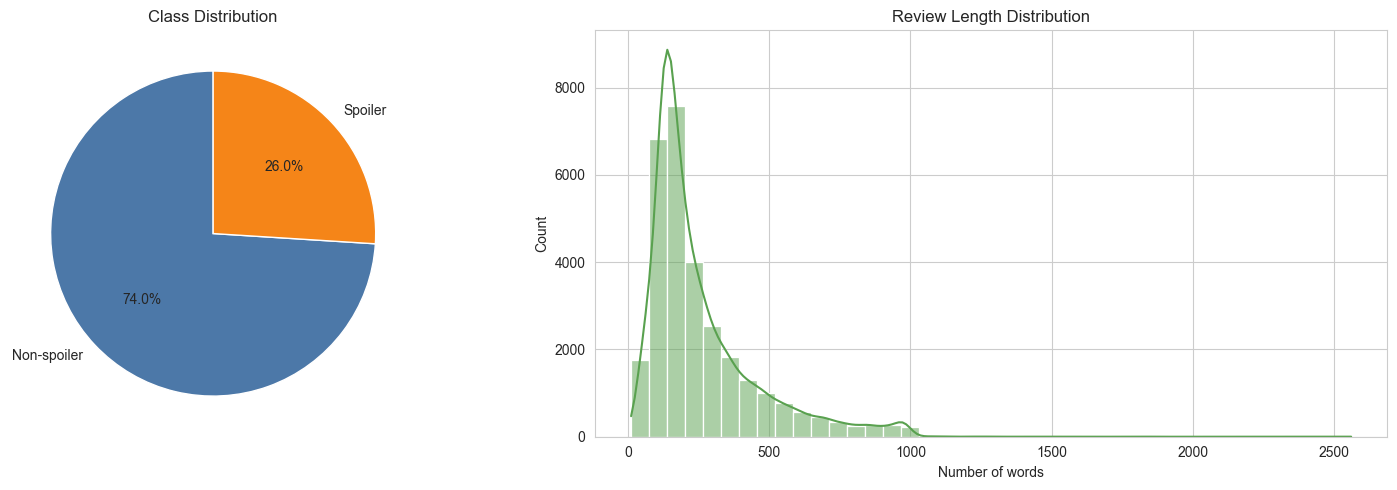

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = data['is_spoiler'].value_counts().sort_index()
axes[0].pie(
    counts,
    labels=['Non-spoiler', 'Spoiler'],
    autopct='%.1f%%',
    colors=['#4C78A8', '#F58518'],
    startangle=90,
)
axes[0].set_title('Class Distribution')

sns.histplot(data['review_length'], bins=40, kde=True, ax=axes[1], color='#59A14F')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


**Baseline analysis results:**

- The data is moderately imbalanced, so accuracy alone is not enough.
- Reviews have a long-tailed length distribution, which means some comments are far longer than others.
- This is useful to keep in mind because longer reviews may carry more spoiler cues.


## 5. Raw Text Examples

To make the task concrete, we show one short spoiler review and one short non-spoiler review.
Only reviews with fewer than 100 words are displayed.


In [15]:
short_reviews = data.loc[data['review_text'].str.split().str.len() < 100].copy()
short_spoiler = short_reviews.loc[short_reviews['is_spoiler'] == 1].head(1)
short_non_spoiler = short_reviews.loc[short_reviews['is_spoiler'] == 0].head(1)

with pd.option_context('display.max_colwidth', None):
    print('Short spoiler example')
    display(short_spoiler[['is_spoiler', 'review_text']])
    print('Short non-spoiler example')
    display(short_non_spoiler[['is_spoiler', 'review_text']])


Short spoiler example


,is_spoiler,review_text
51,1,"When I saw this movie I had not seen any trailer or heard really anything. All I had seen was the poster for the movie and a rumor that it had to do with the getting the plans of the deathstar which is used in episode 4. I was expecting and really hopping for a Star Wars story that had nothing with the main story. A individual and unique story where all characters where new. But what I got was episode 3.5. It was OK, with many good scenes, but the story felt rushed forward."


Short non-spoiler example


,is_spoiler,review_text
8,0,"This is the kind of movie that is you are supposed to think is all deep and wonderful but you will probably hate. Has great talent, but frankly, as any truthful actor (or writer) will tell you - it's oh so much easier to do sturm und drang than it is to be funny. This sort of movie makes me think i'd rather stay home and open a vein. Life has enough deep, dark, ugly moments, i would rather not pay for the privilege."


## 6. Advanced Experiments

### 6.1 Data Preprocessing

The final pipeline uses stemming after a light cleaning step.
This keeps the workflow simple while reducing vocabulary sparsity.


In [16]:
demo_raw = short_spoiler.iloc[0]['review_text']
demo_stemmed = stemming_clean(demo_raw)

preview_df = pd.DataFrame([
    {'version': 'raw', 'words': len(demo_raw.split()), 'text': demo_raw},
    {'version': 'stemmed', 'words': len(demo_stemmed.split()), 'text': demo_stemmed},
])

with pd.option_context('display.max_colwidth', None):
    display(preview_df)


,version,words,text
0,raw,95,"When I saw this movie I had not seen any trailer or heard really anything. All I had seen was the poster for the movie and a rumor that it had to do with the getting the plans of the deathstar which is used in episode 4. I was expecting and really hopping for a Star Wars story that had nothing with the main story. A individual and unique story where all characters where new. But what I got was episode 3.5. It was OK, with many good scenes, but the story felt rushed forward."
1,stemmed,96,when i saw thi movi i had not seen ani trailer or heard realli anyth all i had seen wa the poster for the movi and a rumor that it had to do with the get the plan of the deathstar which is use in episod 4 i wa expect and realli hop for a star war stori that had noth with the main stori a individu and uniqu stori where all charact where new but what i got wa episod 3 5 it wa ok with mani good scene but the stori felt rush forward


**Text cleaning strategy:**

- Lowercase the text.
- Remove URLs and most punctuation.
- Apply Porter stemming.

This is deliberately lightweight, because the goal is a clear demonstration rather than a heavy preprocessing pipeline.


In [17]:
train_df, test_df = group_movie_split(data, test_size=0.15, random_state=RANDOM_SEED)
train_df, val_df = group_movie_split(train_df, test_size=0.15, random_state=RANDOM_SEED)

print(f'Train size: {len(train_df):,}')
print(f'Validation size: {len(val_df):,}')
print(f'Test size: {len(test_df):,}')
print(f'Train spoiler rate: {train_df["is_spoiler"].mean():.3f}')
print(f'Validation spoiler rate: {val_df["is_spoiler"].mean():.3f}')
print(f'Test spoiler rate: {test_df["is_spoiler"].mean():.3f}')


Train size: 21,909
Validation size: 3,623
Test size: 4,468
Train spoiler rate: 0.259
Validation spoiler rate: 0.260
Test spoiler rate: 0.267


### 6.2 Feature Extraction

We now convert the stemmed text into word-level TF-IDF features.


In [18]:
train_clean = train_df['review_text'].map(stemming_clean)
val_clean = val_df['review_text'].map(stemming_clean)
test_clean = test_df['review_text'].map(stemming_clean)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    lowercase=False,
)

X_train_vec = vectorizer.fit_transform(train_clean)
X_val_vec = vectorizer.transform(val_clean)
X_test_vec = vectorizer.transform(test_clean)

print(f'Train matrix shape: {X_train_vec.shape}')
print(f'Validation matrix shape: {X_val_vec.shape}')
print(f'Test matrix shape: {X_test_vec.shape}')
print(f'Vocabulary size: {len(vectorizer.get_feature_names_out()):,}')


Train matrix shape: (21909, 375221)
Validation matrix shape: (3623, 375221)
Test matrix shape: (4468, 375221)
Vocabulary size: 375,221


In [19]:
majority_class = int(train_df['is_spoiler'].mode().iloc[0])
val_majority_pred = np.full(len(val_df), majority_class)
test_majority_pred = np.full(len(test_df), majority_class)

best_lr = LogisticRegression(max_iter=2000, C=best_c, class_weight='balanced')
best_lr.fit(vstack([X_train_vec, X_val_vec]), pd.concat([train_df['is_spoiler'], val_df['is_spoiler']]))

val_lr_pred = best_lr.predict(X_val_vec)
test_lr_pred = best_lr.predict(X_test_vec)

baseline_val_scores = summarize_predictions(val_df['is_spoiler'], val_majority_pred)
baseline_test_scores = summarize_predictions(test_df['is_spoiler'], test_majority_pred)
lr_val_scores = summarize_predictions(val_df['is_spoiler'], val_lr_pred)
lr_test_scores = summarize_predictions(test_df['is_spoiler'], test_lr_pred)

comparison_df = pd.DataFrame([
    {
        'model': 'Majority baseline',
        'validation_accuracy': baseline_val_scores['accuracy'],
        'validation_f1': baseline_val_scores['binary_scores']['f1'],
        'test_accuracy': baseline_test_scores['accuracy'],
        'test_f1': baseline_test_scores['binary_scores']['f1'],
    },
    {
        'model': f'Logistic Regression (C={best_c})',
        'validation_accuracy': lr_val_scores['accuracy'],
        'validation_f1': lr_val_scores['binary_scores']['f1'],
        'test_accuracy': lr_test_scores['accuracy'],
        'test_f1': lr_test_scores['binary_scores']['f1'],
    },
])
comparison_df


NameError: name 'best_c' is not defined

### 6.3 Model Development and Tuning

We tune Logistic Regression with a small grid over `C` values and compare validation performance.


In [ ]:
param_grid = [0.1, 1.0, 10.0]
val_rows = []
best_c = None
best_val_f1 = -1
best_lr = None

for c in param_grid:
    lr = LogisticRegression(max_iter=2000, C=c, class_weight='balanced')
    lr.fit(X_train_vec, train_df['is_spoiler'])
    val_pred = lr.predict(X_val_vec)
    scores = summarize_predictions(val_df['is_spoiler'], val_pred)
    val_rows.append({
        'C': c,
        'validation_accuracy': scores['accuracy'],
        'validation_precision': scores['binary_scores']['precision'],
        'validation_recall': scores['binary_scores']['recall'],
        'validation_f1': scores['binary_scores']['f1'],
    })
    if scores['binary_scores']['f1'] > best_val_f1:
        best_val_f1 = scores['binary_scores']['f1']
        best_c = c
        best_lr = lr

val_results = pd.DataFrame(val_rows).sort_values('validation_f1', ascending=False).reset_index(drop=True)
val_results


### 6.4 Performance Comparison

We compare a majority-class baseline against the tuned Logistic Regression model.


In [ ]:
majority_class = int(train_df['is_spoiler'].mode().iloc[0])
val_majority_pred = np.full(len(val_df), majority_class)
test_majority_pred = np.full(len(test_df), majority_class)

best_lr = LogisticRegression(max_iter=2000, C=best_c, class_weight='balanced')
best_lr.fit(pd.concat([train_clean, val_clean]), pd.concat([train_df['is_spoiler'], val_df['is_spoiler']]))

val_lr_pred = best_lr.predict(pd.concat([X_train_vec, X_val_vec]).tocsr() if False else vectorizer.transform(pd.concat([train_clean, val_clean])))
# Recompute predictions explicitly for the existing validation and test sets.
val_lr_pred = best_lr.predict(X_val_vec)
test_lr_pred = best_lr.predict(X_test_vec)

baseline_val_scores = summarize_predictions(val_df['is_spoiler'], val_majority_pred)
baseline_test_scores = summarize_predictions(test_df['is_spoiler'], test_majority_pred)
lr_val_scores = summarize_predictions(val_df['is_spoiler'], val_lr_pred)
lr_test_scores = summarize_predictions(test_df['is_spoiler'], test_lr_pred)

comparison_df = pd.DataFrame([
    {
        'model': 'Majority baseline',
        'validation_accuracy': baseline_val_scores['accuracy'],
        'validation_f1': baseline_val_scores['binary_scores']['f1'],
        'test_accuracy': baseline_test_scores['accuracy'],
        'test_f1': baseline_test_scores['binary_scores']['f1'],
    },
    {
        'model': f'Logistic Regression (C={best_c})',
        'validation_accuracy': lr_val_scores['accuracy'],
        'validation_f1': lr_val_scores['binary_scores']['f1'],
        'test_accuracy': lr_test_scores['accuracy'],
        'test_f1': lr_test_scores['binary_scores']['f1'],
    },
])
comparison_df


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm = confusion_matrix(test_df['is_spoiler'], test_lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-spoiler', 'Spoiler'])
disp.plot(ax=ax, cmap='YlGnBu', colorbar=False)
ax.set_title(f'Logistic Regression Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


In [ ]:
y_prob = best_lr.predict_proba(X_test_vec)[:, 1]
fpr, tpr, _ = roc_curve(test_df['is_spoiler'], y_prob, pos_label=1)
roc_auc = roc_auc_score(test_df['is_spoiler'], y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### 6.5 Error Analysis

The following table shows a few misclassified reviews.
These are the cases that are most useful to discuss in the recorded demonstration.


In [ ]:
error_frame = test_df[['movie_id', 'is_spoiler', 'review_text']].copy()
error_frame['predicted_spoiler'] = test_lr_pred
error_frame['prob_spoiler'] = y_prob
error_frame['correct'] = error_frame['is_spoiler'] == error_frame['predicted_spoiler']
error_frame['confidence'] = np.where(error_frame['predicted_spoiler'] == 1, error_frame['prob_spoiler'], 1 - error_frame['prob_spoiler'])

mistakes = error_frame.loc[~error_frame['correct']].sort_values('confidence', ascending=False).head(8)
with pd.option_context('display.max_colwidth', None):
    display(mistakes[['movie_id', 'is_spoiler', 'predicted_spoiler', 'prob_spoiler', 'review_text']])


### 6.6 Top Spoiler Cues

The strongest positive coefficients show which words push the Logistic Regression model toward the spoiler class.


In [ ]:
feature_names = np.asarray(vectorizer.get_feature_names_out())
coefficients = best_lr.coef_[0]

pos_idx = np.argsort(coefficients)[-20:][::-1]
neg_idx = np.argsort(coefficients)[:20]

top_spoiler_cues = pd.DataFrame({
    'feature': feature_names[pos_idx],
    'weight': coefficients[pos_idx],
})

top_non_spoiler_cues = pd.DataFrame({
    'feature': feature_names[neg_idx],
    'weight': coefficients[neg_idx],
})

print('Top spoiler cues')
display(top_spoiler_cues)
print('Top non-spoiler cues')
display(top_non_spoiler_cues)


## 7. Overall Conclusion

**Best model:**

- Logistic Regression with TF-IDF features and stemming performs the best in this notebook.

**Main insights:**

- Stemming reduces sparsity and keeps the pipeline compact.
- TF-IDF features expose the text patterns that are most strongly associated with spoilers.
- Error analysis shows that indirect spoilers and subtle wording remain difficult.
- A linear model is especially useful because it is easy to interpret.


## 8. Additional Information

### Libraries and Tools Used

| Library/Tool | Purpose |
|---|---|
| Python | Main programming language |
| pandas | Data loading and tabular processing |
| numpy | Numerical operations |
| matplotlib | Plotting |
| seaborn | Statistical visualization |
| NLTK | Stemming |
| scikit-learn | TF-IDF, Logistic Regression, evaluation |

### Resources

- IMDb review and movie metadata files in the coursework workspace
- scikit-learn documentation
- NLTK stemming documentation
